# **Predicting Airfoil Self-Noise with Machine Learning**

This notebook develops and evaluates machine learning regression models for predicting the scaled sound pressure level (SPL) generated by a NACA 0012 airfoil from its operating and geometric conditions.

The investigation compares baseline and nonlinear regression methods, examines the effects of model complexity and feature selection, and evaluates how well the models generalise to an airfoil chord length that is not represented during model training.

All model development and parameter selection are performed using the development data, while a complete chord length is withheld for final evaluation.

In [1]:
# Clone the project repository when running in a fresh Colab session
import os

REPO_PATH = "/content/MMA3001-Airfoil_Self_Noise_Project"

if not os.path.exists(REPO_PATH):
    !git clone https://github.com/lkoc0002/MMA3001-Airfoil_Self_Noise_Project.git

%cd $REPO_PATH

/content/MMA3001-Airfoil_Self_Noise_Project


In [2]:
# Standard library
import cProfile
import io
import pstats
import time
import tracemalloc

# Importing functions
from src.Airfoil_Functions import (
    FEATURE_COLUMNS,
    evaluate_loco,
    median_ms,
    validate_airfoil_input,
)

# Numerical computing and data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Machine learning
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    GroupKFold,
    KFold,
    LeaveOneGroupOut,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    PolynomialFeatures,
    StandardScaler,
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Reproducibility
RANDOM_STATE = 42

In [3]:
# Define column names for the Airfoil Self-Noise dataset
COLUMN_NAMES = [
    "frequency",
    "angle_of_attack",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
    "sound_pressure_level",
]

# Primary dataset location in the project GitHub repository
DATA_URL = (
    "https://raw.githubusercontent.com/lkoc0002/MMA3001-Airfoil_Self_Noise_Project/refs/heads/main/data/airfoil_self_noise.dat"
)

try:
    # Load directly from the project repository
    df = pd.read_csv(
        DATA_URL,
        sep="\t",
        names=COLUMN_NAMES,
    )

except Exception:
    # Fall back to a local copy if the remote file is unavailable
    df = pd.read_csv(
        "airfoil_self_noise.dat",
        sep="\t",
        names=COLUMN_NAMES,
    )

# Confirm that the expected dataset has been loaded
assert df.shape == (1503, 6), "Unexpected dataset shape."
assert not df.isna().any().any(), "Dataset contains missing values."


## 1. Engineering Problem and Objectives

Airfoil self-noise is generated by the interaction between airflow and an airfoil surface. Predicting this noise from known operating and geometric conditions provides an engineering regression problem that can be investigated using machine learning.

This project develops a machine learning model for predicting the **scaled sound pressure level (SPL)** generated by a NACA 0012 airfoil using acoustic frequency, angle of attack, chord length, free stream velocity and displacement thickness as inputs.

The central investigation is whether a model trained on measured airfoil configurations can accurately predict SPL for a **chord length not represented during training**.

Several regression methods are therefore developed and compared against simple baseline models. Model selection is performed using leave one chord out validation, before the selected models are evaluated on an untouched chord length of **0.1524 m**.

Such a model could provide a computational surrogate for estimating airfoil noise under experimental conditions, allowing the effects of different conditions to be investigated without requiring costly physical measurements for every combination.

### Objectives

The investigation aims to:

1. Establish simple baseline models against which more complex regression methods can be compared.
2. Investigate whether nonlinear relationships improve SPL prediction compared with multiple linear regression.
3. Examine the effect of model complexity and identify evidence of underfitting and overfitting.
4. Investigate the contribution of individual predictor variables to model performance.
5. Compare polynomial regression, decision tree regression and support vector regression (SVR).
6. Select model complexity and hyperparameters using validation in which complete chord lengths are withheld.
7. Evaluate the selected models on an untouched chord length excluded from model development.
8. Compare interpolation to unseen interior chord lengths with extrapolation to chord lengths at the edges of the measured range.
9. Examine prediction residuals, computational cost and model limitations.

The overall engineering question is:

> **How accurately can machine learning regression models predict airfoil sound pressure level from measured operating and geometric variables, and how well do these models generalise to a chord length not represented during training?**

### Scope

The investigation is limited to the operating and geometric conditions represented in the Airfoil Self-Noise dataset and to the NACA 0012 airfoil used in those experiments.

The dataset contains only six discrete chord lengths and four free stream velocities. The results therefore provide evidence of predictive performance within the range and structure of this experimental dataset. They should not be interpreted as demonstrating generalisation to different airfoil geometries or to operating conditions outside the measured range.

### Inputs and Output

| Variable | Symbol | Meaning | Unit | Range in Dataset |
|---|---:|---|---:|---:|
| Frequency | \(f\) | Acoustic frequency | Hz | 200–20,000 |
| Angle of attack | \(\alpha\) | Airfoil angle relative to the incoming flow | ° | 0–22.2 |
| Chord length | \(c\) | Airfoil chord length | m | 0.0254–0.3048 |
| Free-stream velocity | \(U\) | Incoming airflow velocity | m/s | 31.7–71.3 |
| Displacement thickness | \(\delta\) | Suction-side displacement thickness | m | 0.0004007–0.05841 |
| **Output: Sound pressure level** | **SPL** | **Scaled sound pressure level** | **dB** | **103.38–140.99** |

The five input variables form the predictor vector

$X=(f,\alpha,c,U,\delta)$

and the regression target is

$y=\mathrm{SPL}$.

Prediction error is reported in decibels using MAE and RMSE, while (R^2) is used to describe the proportion of variation in SPL explained by each model. Model performance is assessed relative to the baseline models and across error metrics.

## 2. Dataset and Experimental Structure

The dataset contains 1,503 measurements collected across a set of airfoil geometries and operating conditions. Before selecting a validation strategy, the structure of these measurements is examined to determine whether observations can reasonably be treated as independent samples.

In [4]:
# Target variable used by the regression models
TARGET_COLUMN = "sound_pressure_level"

# Summarise the experimental values represented by each predictor
input_summary = pd.DataFrame({
    "Unique Values": df[FEATURE_COLUMNS].nunique(),
    "Minimum": df[FEATURE_COLUMNS].min(),
    "Maximum": df[FEATURE_COLUMNS].max(),
})

display(input_summary)

,Unique Values,Minimum,Maximum
frequency,21,200.000000,20000.000000
angle_of_attack,27,0.000000,22.200000
chord_length,6,0.025400,0.304800
free_stream_velocity,4,31.700000,71.300000
displacement_thickness,105,0.000401,0.058411


In [5]:
# Non-frequency variables defining an experimental condition
CONDITION_COLUMNS = [
    "angle_of_attack",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
]

# Assign each experimental condition a unique identifier
df["condition_id"] = (
    df.groupby(CONDITION_COLUMNS)
    .ngroup()
)

# Count frequency measurements belonging to each condition
condition_counts = (
    df.groupby("condition_id")
    .size()
)

print(f"Experimental conditions: {condition_counts.size}")
print(
    "Mean observations per condition: "
    f"{condition_counts.mean():.1f}"
)
print(
    "Range of observations per condition: "
    f"{condition_counts.min()}–{condition_counts.max()}"
)

Experimental conditions: 106
Mean observations per condition: 14.2
Range of observations per condition: 8–19


In [6]:
# Summarise the amount of experimental data available at each chord length
chord_summary = (
    df.groupby("chord_length")
    .agg(
        observations=("sound_pressure_level", "size"),
        experimental_conditions=("condition_id", "nunique"),
    )
    .reset_index()
)

display(chord_summary)

,chord_length,observations,experimental_conditions
0,0.0254,278,20
1,0.0508,237,18
2,0.1016,263,20
3,0.1524,271,18
4,0.2286,266,18
5,0.3048,188,12


## 3. Validation Design

### Withheld Test Chord

The primary objective of the validation strategy is to assess whether a model can predict SPL for a chord length that was not represented during training.

The chord length **0.1524 m** is therefore reserved as an untouched test set. All observations associated with this chord are excluded from feature selection, model selection and hyperparameter tuning.

This chord was selected because it lies between two chord lengths available to the model (0.1016 and 0.2286).

The final evaluation therefore represents interpolation to an unseen chord length rather than extrapolation beyond the measured chord range.

### Model Development

The remaining five chord lengths form the development dataset.

During each validation fold, one complete  chord is withheld and the model is trained on the remaining four chords.

This allows model parameters to be chosen according to their ability to generalise to chord lengths missing from the corresponding training data.

The untouched 0.1524 m test chord is evaluated only after model development and model selection are complete.

In [7]:
# Chord length reserved for final model evaluation
TEST_CHORD = 0.1524

# Separate the untouched test chord from the development data
test_mask = np.isclose(
    df["chord_length"],
    TEST_CHORD,
)

development_df = df.loc[~test_mask].copy()
test_df = df.loc[test_mask].copy()

# Define development and test predictors and targets
X_development = development_df[FEATURE_COLUMNS]
y_development = development_df[TARGET_COLUMN]

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

# Chord length defines the validation groups
development_groups = development_df["chord_length"]

# Verify that the test chord is completely absent from development data
assert not np.isclose(
    development_df["chord_length"],
    TEST_CHORD,
).any(), "Test chord found in development data."

print(
    "\nDevelopment chord lengths:",
    np.sort(development_df["chord_length"].unique()),
)

print(
    "Withheld test chord:",
    test_df["chord_length"].unique(),
)


Development chord lengths: [0.0254 0.0508 0.1016 0.2286 0.3048]
Withheld test chord: [0.1524]


In [8]:
# Assign each development observation to its chord-length group
development_groups = development_df["chord_length"].to_numpy()

# Leave one complete development chord out in each validation fold
logo = LeaveOneGroupOut()

print(f"Number of validation folds: {logo.get_n_splits(groups=development_groups)}")

# Display the chord used for validation in each fold
for fold, (train_idx, validation_idx) in enumerate(
    logo.split(
        X_development,
        y_development,
        groups=development_groups,
    ),
    start=1,
):
    training_chords = np.unique(
        development_groups[train_idx]
    )

    validation_chord = np.unique(
        development_groups[validation_idx]
    )

    print(
        f"Fold {fold}: "
        f"train chords = {training_chords}, "
        f"validation chord = {validation_chord}"
    )

Number of validation folds: 5
Fold 1: train chords = [0.0508 0.1016 0.2286 0.3048], validation chord = [0.0254]
Fold 2: train chords = [0.0254 0.1016 0.2286 0.3048], validation chord = [0.0508]
Fold 3: train chords = [0.0254 0.0508 0.2286 0.3048], validation chord = [0.1016]
Fold 4: train chords = [0.0254 0.0508 0.1016 0.3048], validation chord = [0.2286]
Fold 5: train chords = [0.0254 0.0508 0.1016 0.2286], validation chord = [0.3048]


## 4. Baseline Regression Models

Two simple regression models are first evaluated to establish baseline prediction performance.

A **mean predictor** ignores the input variables and always predicts the mean SPL of the training data. This provides a minimum benchmark that a useful regression model should improve upon.

A **multiple linear regression model** then uses all five predictor variables. This tests how well SPL can be represented using a simple linear combination of the available inputs before nonlinear model complexity is introduced.

Both models are evaluated using the same validation process where one chord is left out for model selection.

In [9]:
# Mean predictor: always predicts the mean SPL of the training data
mean_model = DummyRegressor(strategy="mean")

# Multiple linear regression using all five input variables
linear_model = LinearRegression()

mean_results = evaluate_loco(
    mean_model,
    X_development,
    y_development,
    development_groups,
)

linear_results = evaluate_loco(
    linear_model,
    X_development,
    y_development,
    development_groups,
)

baseline_results = pd.DataFrame({
    "Model": [
        "Mean Predictor",
        "Linear Regression",
    ],
    "Mean LOCO RMSE": [
        mean_results["RMSE"].mean(),
        linear_results["RMSE"].mean(),
    ],
    "RMSE Std": [
        mean_results["RMSE"].std(),
        linear_results["RMSE"].std(),
    ],
})

display(baseline_results.round(3))

,Model,Mean LOCO RMSE,RMSE Std
0,Mean Predictor,6.839,0.690
1,Linear Regression,5.002,1.664


## 5. Polynomial Regression and Model Complexity

The relationships causing airfoil noise may be nonlinear and may also involve interactions between all variables.

Polynomial regression is therefore investigated to introduce nonlinear terms and interactions.

Increasing polynomial degree also increases the number of model features and therefore the risk of overfitting. Polynomial degree is varied systematically and evaluated using same one chord removed validation strategy to evaluate the trade off between model complexity and generalisation.

### Feature Scaling for Polynomial Regression

The predictor variables have different numerical scales. For example, frequency reaches 20,000 Hz while displacement thickness is typically much smaller than one metre.

Polynomial expansion increases these differences in scale. Standardisation is applied before polynomial expansion to improve the numerical conditioning of the regression problem. The scaler is fitted separately within each training fold to prevent information from the validation chord entering model development.


In [10]:
# Investigate polynomial complexity using scaled predictors
POLYNOMIAL_DEGREES = range(1, 6)

scaled_polynomial_results = []

for degree in POLYNOMIAL_DEGREES:

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "polynomial_features",
            PolynomialFeatures(
                degree=degree,
                include_bias=False,
            ),
        ),
        ("linear_regression", LinearRegression()),
    ])

    # Evaluate training and validation error using the same LOCO folds
    cv_results = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )

    scaled_polynomial_results.append({
        "Degree": degree,
        "Train RMSE": cv_results["Train RMSE"].mean(),
        "Mean LOCO RMSE": cv_results["RMSE"].mean(),
        "RMSE Std": cv_results["RMSE"].std(),
    })

scaled_polynomial_results = pd.DataFrame(
    scaled_polynomial_results
)

display(scaled_polynomial_results.round(3))

,Degree,Train RMSE,Mean LOCO RMSE,RMSE Std
0,1,4.778,5.002,1.664
1,2,4.072,6.030,3.734
2,3,3.290,51.807,59.241
3,4,2.497,41992.100,55406.341
4,5,2.071,31695.630,50596.372


The model produced the expected reduction in training error as polynomial degree increased. However, validation error became extremely large for degree 3 and above, showing that the higher order polynomial models were unstable when predicting chord lengths excluded from training. Increasing polynomial complexity therefore improved the fit to the development data but reduced generalisation.

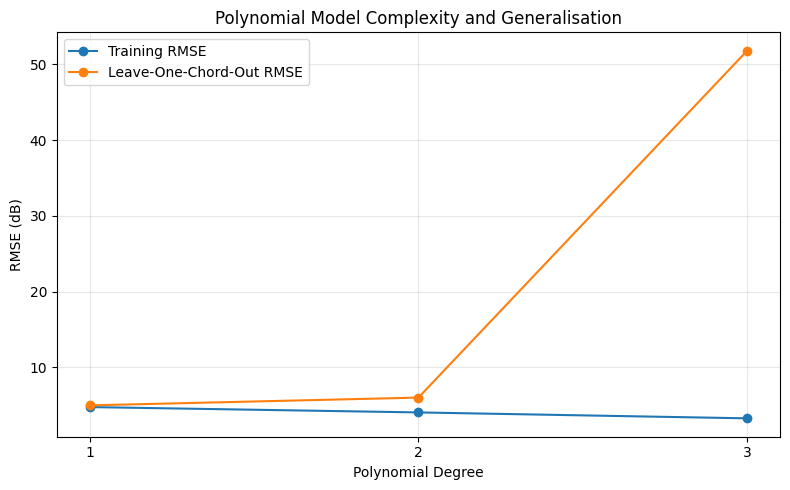

In [11]:
# Focus the complexity plot on degrees 1-3 so the useful error
# differences remain visible. Higher-degree failures remain in the table.
plot_results = scaled_polynomial_results[
    scaled_polynomial_results["Degree"] <= 3
]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_results["Degree"],
    plot_results["Train RMSE"],
    marker="o",
    label="Training RMSE",
)

plt.plot(
    plot_results["Degree"],
    plot_results["Mean LOCO RMSE"],
    marker="o",
    label="Leave-One-Chord-Out RMSE",
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE (dB)")
plt.title("Polynomial Model Complexity and Generalisation")
plt.xticks(plot_results["Degree"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Compare degree-1, degree-2 and degree-3 performance by withheld chord
per_chord_results = []

for degree in [1, 2, 3]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "polynomial_features",
            PolynomialFeatures(
                degree=degree,
                include_bias=False,
            ),
        ),
        ("linear_regression", LinearRegression()),
    ])

    cv_results = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )

    cv_results["Degree"] = degree
    per_chord_results.append(cv_results)

per_chord_results = pd.concat(
    per_chord_results,
    ignore_index=True,
)

per_chord_table = per_chord_results.pivot(
    index="Withheld Chord",
    columns="Degree",
    values="RMSE",
)

per_chord_table.columns = [
    f"Degree {degree}"
    for degree in per_chord_table.columns
]

display(per_chord_table.round(3))

,Degree 1,Degree 2,Degree 3
Withheld Chord,,,
0.0254,7.759,12.702,68.481
0.0508,4.233,4.313,8.381
0.1016,5.164,4.660,148.443
0.2286,4.452,4.287,10.020
0.3048,3.403,4.187,23.709


Increasing polynomial degree reduced training RMSE from 4.778 dB for degree 1 to 2.071 dB for degree 5, indicating an increasingly close fit to the development data. However, this improvement did not translate to unseen chord lengths. Mean leave one chord out RMSE increased from 5.002 dB for degree 1 to 6.030 dB for degree 2 and became unstable from degree 3 onwards. The per chord results show that this instability was not limited to edge chord extrapolation, since degree 3 also produced very large error when 0.1016 m was withheld. Among the polynomial models tested, degree 1 produced the lowest mean leave one chord out RMSE.

Therefore, additional polynomial complexity increased overfitting without improving generalisation to unseen chord lengths.

In [13]:
# Examine numerical conditioning of the polynomial feature matrices
polynomial_diagnostics = []

for degree in POLYNOMIAL_DEGREES:

    # Apply the same scaling used by the polynomial regression pipeline
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_development)

    # Generate polynomial features
    polynomial = PolynomialFeatures(
        degree=degree,
        include_bias=False,
    )

    X_polynomial = polynomial.fit_transform(X_scaled)

    polynomial_diagnostics.append({
        "Degree": degree,
        "Number of Features": X_polynomial.shape[1],
        "Matrix Rank": np.linalg.matrix_rank(X_polynomial),
        "Condition Number": np.linalg.cond(X_polynomial),
    })

polynomial_diagnostics = pd.DataFrame(
    polynomial_diagnostics
)

display(polynomial_diagnostics)

,Degree,Number of Features,Matrix Rank,Condition Number
0,1,5,5,3.697791e+00
1,2,20,20,4.784847e+01
2,3,55,55,2.853830e+03
3,4,125,125,1.465311e+06
4,5,251,213,1.602052e+18


Higher polynomial degrees increased the number of generated features and worsened the numerical conditioning of the feature matrix. Degrees 1–4 retained full numerical rank after standardisation, while degree 5 became rank deficient with a rank of 213 across 251 generated features.

The large validation errors at degrees 3 and 4 therefore cannot be attributed to rank deficiency alone. Combined with lower training errors, the results indicate that higher order polynomial models fit the training data closely, but generalise poorly when an entire chord length is withheld.

Degree 2 is therefore used as the nonlinear polynomial model for future comparison.

## 6. Decision Tree Regression

Decision tree regression is investigated as an alternative nonlinear approach. Unlike polynomial regression, a decision tree divides the predictor space into regions and produces predictions from the observations within those regions.

Tree depth controls model complexity. A shallow tree may underfit the data, while a very deep tree can closely fit the training observations but may generalise poorly to unseen chord lengths.

Maximum tree depth is therefore varied systematically. Training RMSE and leave one chord out validation RMSE are compared to evaluate model fit and generalisation.

In [14]:
# Investigate the effect of maximum tree depth
TREE_DEPTHS = range(1, 21)

tree_results = []

for depth in TREE_DEPTHS:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE,
    )

    # Evaluate training and validation error using the same LOCO folds
    cv_results = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )

    tree_results.append({
        "Max Depth": depth,
        "Train RMSE": cv_results["Train RMSE"].mean(),
        "Mean LOCO RMSE": cv_results["RMSE"].mean(),
        "RMSE Std": cv_results["RMSE"].std(),
    })

tree_results = pd.DataFrame(tree_results)

display(tree_results.round(3))

,Max Depth,Train RMSE,Mean LOCO RMSE,RMSE Std
0,1,6.181,7.319,1.076
1,2,5.327,6.159,1.033
2,3,4.774,5.682,1.160
3,4,4.241,5.384,1.180
4,5,3.744,5.258,1.047
5,6,3.213,5.005,0.994
6,7,2.686,4.907,1.428
7,8,2.217,4.747,1.461
8,9,1.753,4.800,1.549
9,10,1.347,5.058,1.521


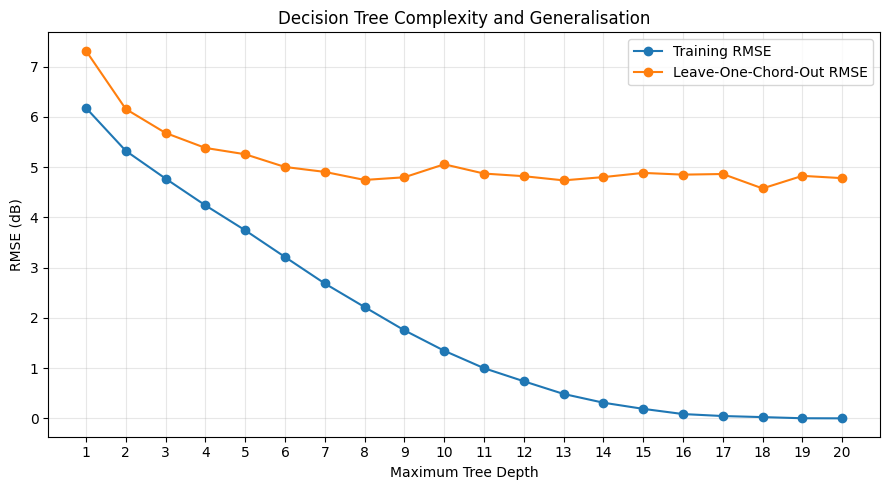

In [15]:
# Visualise training and validation error as tree complexity increases
plt.figure(figsize=(9, 5))

plt.plot(
    tree_results["Max Depth"],
    tree_results["Train RMSE"],
    marker="o",
    label="Training RMSE",
)

plt.plot(
    tree_results["Max Depth"],
    tree_results["Mean LOCO RMSE"],
    marker="o",
    label="Leave-One-Chord-Out RMSE",
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("RMSE (dB)")
plt.title("Decision Tree Complexity and Generalisation")
plt.xticks(range(1, 21))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Select a moderate tree depth after examining the complexity curve.
# Depth 8 captures most of the validation improvement while avoiding
# the near-zero training error observed for substantially deeper trees.
SELECTED_TREE_DEPTH = 8

selected_tree = tree_results.loc[
    tree_results["Max Depth"] == SELECTED_TREE_DEPTH
].iloc[0]

minimum_tree = tree_results.loc[
    tree_results["Mean LOCO RMSE"].idxmin()
]

print(
    f"Selected tree depth: {SELECTED_TREE_DEPTH}\n"
    f"LOCO RMSE at selected depth: "
    f"{selected_tree['Mean LOCO RMSE']:.3f} dB\n"
    f"Minimum observed LOCO RMSE: "
    f"{minimum_tree['Mean LOCO RMSE']:.3f} dB "
    f"(depth {int(minimum_tree['Max Depth'])})"
)

Selected tree depth: 8
LOCO RMSE at selected depth: 4.747 dB
Minimum observed LOCO RMSE: 4.578 dB (depth 18)


Validation error decreased as depth increased from 1 to 8, showing that shallow trees underfit the data. Beyond this, training error continued toward zero while validation performance showed little improvement.

Although depth 18 produced the lowest mean LOCO RMSE, depth 8 was retained as a simpler model with less training overfit and similar validation performance.

## 7. Support Vector Regression

Radial basis function support vector regression (RBF SVR) is investigated as a third nonlinear modelling approach.

Unlike polynomial regression, nonlinear behaviour is represented through the RBF kernel rather than explicit polynomial terms. Unlike a decision tree, the resulting prediction function is smooth rather than piecewise constant.

The SVR model is sensitive to the numerical scale of its inputs, so predictor variables are standardised within the modelling pipeline. This ensures that scaling is fitted only to the training data within each validation fold.

Two hyperparameters control model behaviour:

- `C` controls the penalty applied to prediction errors.
- `gamma` controls the spatial influence of individual training observations in the RBF kernel.

These parameters are investigated using leave one chord out validation.

In [17]:
# Investigate the effect of the SVR regularisation parameter C
C_VALUES = [0.1, 1, 10, 100, 1000, 3000]

svr_c_results = []

for c_value in C_VALUES:

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svr",
            SVR(
                kernel="rbf",
                C=c_value,
                gamma="scale",
            ),
        ),
    ])

    cv_results = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )

    svr_c_results.append({
        "C": c_value,
        "Train RMSE": cv_results["Train RMSE"].mean(),
        "Mean LOCO RMSE": cv_results["RMSE"].mean(),
        "RMSE Std": cv_results["RMSE"].std(),
    })

svr_c_results = pd.DataFrame(svr_c_results)

display(svr_c_results.round(3))

,C,Train RMSE,Mean LOCO RMSE,RMSE Std
0,0.1,5.231,5.713,0.723
1,1.0,3.775,4.521,1.363
2,10.0,3.087,4.492,1.060
3,100.0,2.563,4.312,1.215
4,1000.0,2.184,6.010,1.844
5,3000.0,2.053,7.211,2.411


In [18]:
# Investigate the effect of RBF kernel width
GAMMA_VALUES = [
    0.01,
    0.03,
    0.1,
    0.2,
    0.3,
    1.0,
    3.0,
]

svr_gamma_results = []

for gamma in GAMMA_VALUES:

# Investigate gamma while holding C = 100 fixed
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svr",
            SVR(
                kernel="rbf",
                C=100,
                gamma=gamma,
            ),
        ),
    ])

    cv_results = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )

    svr_gamma_results.append({
        "Gamma": gamma,
        "Train RMSE": cv_results["Train RMSE"].mean(),
        "Mean LOCO RMSE": cv_results["RMSE"].mean(),
        "RMSE Std": cv_results["RMSE"].std(),
    })

svr_gamma_results = pd.DataFrame(
    svr_gamma_results
)

display(svr_gamma_results.round(3))

,Gamma,Train RMSE,Mean LOCO RMSE,RMSE Std
0,0.01,4.155,4.516,1.753
1,0.03,3.640,4.359,1.774
2,0.10,2.976,4.986,1.172
3,0.20,2.563,4.312,1.215
4,0.30,2.350,4.296,1.228
5,1.00,1.767,4.722,1.287
6,3.00,1.235,6.251,1.161


Increasing gamma initially improved the ability of the RBF SVR to model the training data, with training RMSE decreasing from 4.155 dB at gamma = 0.01 to 1.235 dB at gamma = 3.0. The lowest mean leave one chord out RMSE was 4.296 dB at gamma = 0.30, although gamma = 0.20 produced a very similar result of 4.312 dB. At larger gamma values, training error continued to decrease while validation error increased, reaching 6.251 dB at gamma = 3.0. This training validation gap indicates overfitting, as the increasingly local RBF model fitted the observed chord lengths more closely without improving prediction of unseen chord lengths.

In [19]:
# Check promising combinations of C and gamma
C_VALUES_FINAL = [10, 100, 300]
GAMMA_VALUES_FINAL = [0.03, 0.20, 0.30]

svr_joint_results = []

for C_value in C_VALUES_FINAL:
    for gamma in GAMMA_VALUES_FINAL:

        model = Pipeline([
            ("scaler", StandardScaler()),
            (
                "svr",
                SVR(
                    kernel="rbf",
                    C=C_value,
                    gamma=gamma,
                ),
            ),
        ])

        cv_results = evaluate_loco(
            model,
            X_development,
            y_development,
            development_groups,
        )

        svr_joint_results.append({
            "C": C_value,
            "Gamma": gamma,
            "Train RMSE": cv_results["Train RMSE"].mean(),
            "Mean LOCO RMSE": cv_results["RMSE"].mean(),
            "RMSE Std": cv_results["RMSE"].std(),
        })

svr_joint_results = pd.DataFrame(
    svr_joint_results
)

svr_joint_results = svr_joint_results.sort_values(
    "Mean LOCO RMSE"
).reset_index(drop=True)

display(svr_joint_results.round(3))

,C,Gamma,Train RMSE,Mean LOCO RMSE,RMSE Std
0,100,0.30,2.350,4.296,1.228
1,100,0.20,2.563,4.312,1.215
2,10,0.30,2.872,4.321,1.035
3,100,0.03,3.640,4.359,1.774
4,10,0.03,4.072,4.364,1.785
5,10,0.20,3.087,4.492,1.060
6,300,0.20,2.364,4.757,1.297
7,300,0.30,2.172,4.938,1.202
8,300,0.03,3.434,5.013,1.429


The joint parameter check produced the lowest mean leave one chord out RMSE of 4.296 dB using (C=100) and (gamma=0.30).  Neighbouring parameter combinations produced very similar validation errors, indicating that the selected values should not be interpreted as the singular best option. The combination (C=100,gamma=0.30) is therefore selected for future comparison.

In [20]:
SELECTED_SVR_C = 100
SELECTED_SVR_GAMMA = 0.30

## 8. Model Comparison

The regression approaches investigated in the previous sections are compared using the same leave one chord out (LOCO) validation process.

The comparison includes:
- a mean predictor as a baseline
- multiple linear regression
- degree 2 polynomial regression as the nonlinear polynomial alternative
- a decision tree with maximum depth 8, and
- RBF support vector regression with $C=100$ and $\gamma=0.30$.

A tree depth of 8 is used because validation error decreased up to this region, while greater depths continued to reduce training error without providing better improvements in validation performance.

Degree 2 polynomial regression is included because degree 1 is equivalent to multiple linear regression and would duplicate the linear baseline. Degree 2 therefore represents the nonlinear polynomial alternative.

The generalisation gap is calculated as the difference between mean LOCO validation RMSE and mean training RMSE across the same folds. It is considered alongside validation performance as an indication of how closely each model fits the training data.

The withheld 0.1524 m test chord remains excluded from all model comparison and selection.

In [21]:
# Model configurations selected from the development experiments
SELECTED_TREE_DEPTH = 8
SELECTED_SVR_C = 100
SELECTED_SVR_GAMMA = 0.30

comparison_models = {
    "Mean Predictor": DummyRegressor(
        strategy="mean",
    ),

    "Multiple Linear Regression": LinearRegression(),

    "Polynomial Regression (degree 2)": Pipeline([
        ("scaler", StandardScaler()),
        (
            "polynomial_features",
            PolynomialFeatures(
                degree=2,
                include_bias=False,
            ),
        ),
        ("linear_regression", LinearRegression()),
    ]),

    "Decision Tree (depth 8)": DecisionTreeRegressor(
        max_depth=SELECTED_TREE_DEPTH,
        random_state=RANDOM_STATE,
    ),

    "RBF SVR": Pipeline([
        ("scaler", StandardScaler()),
        (
            "svr",
            SVR(
                kernel="rbf",
                C=SELECTED_SVR_C,
                gamma=SELECTED_SVR_GAMMA,
            ),
        ),
    ]),
}

comparison_results = []

for model_name, model in comparison_models.items():

    cv_results = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )

    mean_train_rmse = cv_results["Train RMSE"].mean()
    mean_loco_rmse = cv_results["RMSE"].mean()

    comparison_results.append({
        "Model": model_name,
        "Train RMSE": mean_train_rmse,
        "Mean LOCO RMSE": mean_loco_rmse,
        "Generalisation Gap": (
            mean_loco_rmse - mean_train_rmse
        ),
        "RMSE Std": cv_results["RMSE"].std(),
    })

model_comparison = pd.DataFrame(
    comparison_results
)

display(model_comparison.round(3))

,Model,Train RMSE,Mean LOCO RMSE,Generalisation Gap,RMSE Std
0,Mean Predictor,6.727,6.839,0.111,0.690
1,Multiple Linear Regression,4.778,5.002,0.224,1.664
2,Polynomial Regression (degree 2),4.072,6.030,1.957,3.734
3,Decision Tree (depth 8),2.217,4.747,2.530,1.461
4,RBF SVR,2.350,4.296,1.946,1.228


All regression models except degree 2 polynomial regression improved on the mean predictor baseline when evaluated on unseen development chord lengths.

Multiple linear regression reduced mean LOCO RMSE from 6.839 dB to 5.002 dB. Even though degree 2 polynomial regression achieved a lower training RMSE of 4.072 dB, its mean validation RMSE increased to 6.030 dB, highlighting that additional polynomial complexity did not improve generalisation.

The decision tree reduced mean LOCO RMSE to 4.747 dB, while RBF SVR achieved the lowest mean LOCO RMSE of the models compared at 4.296 dB.

The nonlinear tree and SVR models exhibited larger training validation gaps than multiple linear regression, indicating closer fitting to the observed training chords. RBF SVR had the lowest mean validation error and had lower fold RMSE variation than the decision tree.


In [22]:
# Compare each model on the individual withheld development chords
per_chord_model_results = []

for model_name, model in comparison_models.items():

    cv_results = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )

    for _, row in cv_results.iterrows():

        per_chord_model_results.append({
            "Withheld Chord": row["Withheld Chord"],
            "Model": model_name,
            "RMSE": row["RMSE"],
        })

per_chord_model_results = pd.DataFrame(
    per_chord_model_results
)

per_chord_model_table = per_chord_model_results.pivot(
    index="Withheld Chord",
    columns="Model",
    values="RMSE",
)

display(per_chord_model_table.round(3))

Model,Decision Tree (depth 8),Mean Predictor,Multiple Linear Regression,Polynomial Regression (degree 2),RBF SVR
Withheld Chord,,,,,
0.0254,6.207,6.763,7.759,12.702,6.249
0.0508,5.874,6.040,4.233,4.313,3.473
0.1016,5.179,7.751,5.164,4.660,4.783
0.2286,3.676,6.356,4.452,4.287,3.449
0.3048,2.798,7.283,3.403,4.187,3.527


In [23]:
# Identify the lowest-RMSE model for each withheld chord
per_chord_winners = (
    per_chord_model_table
    .idxmin(axis=1)
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Lowest RMSE Chords")
)

display(per_chord_winners)

,Model,Lowest RMSE Chords
0,Decision Tree (depth 8),2
1,RBF SVR,2
2,Polynomial Regression (degree 2),1


No model therefore achieved the lowest error on every withheld chord. RBF SVR produced the lowest mean LOCO RMSE overall, but its advantage over the decision tree was not consistent across all chord lengths.

This supports carrying SVR forward based on its overall validation performance but it does not dominate the alternative models under every condition.

In [24]:
# Compare model performance for interior and edge chord lengths
chord_generalisation_results = []

for model_name, model in comparison_models.items():

    cv_results = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )

    for _, row in cv_results.iterrows():

        withheld_chord = row["Withheld Chord"]

        if np.isclose(
            withheld_chord,
            development_groups.min(),
        ) or np.isclose(
            withheld_chord,
            development_groups.max(),
        ):
            prediction_type = "Edge (extrapolation)"
        else:
            prediction_type = "Interior (interpolation)"

        chord_generalisation_results.append({
            "Model": model_name,
            "Withheld Chord": withheld_chord,
            "Prediction Type": prediction_type,
            "RMSE": row["RMSE"],
        })

chord_generalisation_results = pd.DataFrame(
    chord_generalisation_results
)

edge_interior_summary = (
    chord_generalisation_results
    .groupby(
        ["Model", "Prediction Type"],
        as_index=False,
    )["RMSE"]
    .mean()
)

edge_interior_table = (
    edge_interior_summary
    .pivot(
        index="Model",
        columns="Prediction Type",
        values="RMSE",
    )
    .reset_index()
)

display(edge_interior_table.round(3))

Prediction Type,Model,Edge (extrapolation),Interior (interpolation)
0,Decision Tree (depth 8),4.503,4.910
1,Mean Predictor,7.023,6.716
2,Multiple Linear Regression,5.581,4.616
3,Polynomial Regression (degree 2),8.444,4.420
4,RBF SVR,4.888,3.902


Generalisation performance depended on whether the withheld chord was inside or outside the range represented during training. The RBF SVR achieved a mean RMSE of 3.902 dB for interior chord interpolation compared with 4.888 dB for edge chord extrapolation.

Thus, RBF SVR is carried forward for final evaluation because it achieved the lowest mean LOCO RMSE of 4.296 dB among the models compared. The per chord results show that this advantage is not across every chord length, so the selection is based on overall validation performance rather than consistent superiority in every fold.

Linear regression showed a similar pattern, while degree 2 polynomial regression deteriorated from 4.420 dB for interior chords to 8.444 dB for edge chords.

The decision tree did not show the same behaviour, producing similar errors for interior and edge chords.

Therefore, poorer extrapolation performance was model dependent rather than a consistent outcome of the dataset.

This is important, as the untouched
0.1524m test chord lies within the range of chord lengths available during model development and is interpolation rather than extrapolation.

## 9. Predictor Sensitivity

The contribution of each input variable is investigated by removing one predictor at a time and repeating the removal of one chord validation.

The purpose of this is to determine whether each measured variable provides useful information for SPL prediction. An increase in validation RMSE after removing a predictor indicates that the model loses predictive information when that variable is unavailable.

This analysis describes predictive importance rather than physical causation, since the experimental variables are not varied independently.

In [25]:
# Evaluate the baseline model using all predictors
feature_removal_results = []

all_features_model = LinearRegression()

all_features_cv = evaluate_loco(
    all_features_model,
    X_development,
    y_development,
    development_groups,
)

feature_removal_results.append({
    "Feature Set": "All features",
    "Number of Inputs": len(FEATURE_COLUMNS),
    "Mean LOCO RMSE": all_features_cv["RMSE"].mean(),
    "RMSE Std": all_features_cv["RMSE"].std(),
})

# Remove one predictor at a time
for removed_feature in FEATURE_COLUMNS:

    remaining_features = [
        feature
        for feature in FEATURE_COLUMNS
        if feature != removed_feature
    ]

    model = LinearRegression()

    cv_results = evaluate_loco(
        model,
        X_development[remaining_features],
        y_development,
        development_groups,
    )

    feature_removal_results.append({
        "Feature Set": f"Without {removed_feature}",
        "Number of Inputs": len(remaining_features),
        "Mean LOCO RMSE": cv_results["RMSE"].mean(),
        "RMSE Std": cv_results["RMSE"].std(),
    })

feature_removal_results = pd.DataFrame(
    feature_removal_results
)
# Express the effect of removing each predictor relative to all features
baseline_rmse = feature_removal_results.loc[
    feature_removal_results["Feature Set"] == "All features",
    "Mean LOCO RMSE",
].iloc[0]

feature_removal_results["RMSE Change"] = (
    feature_removal_results["Mean LOCO RMSE"]
    - baseline_rmse
)

display(feature_removal_results.round(3))


,Feature Set,Number of Inputs,Mean LOCO RMSE,RMSE Std,RMSE Change
0,All features,5,5.002,1.664,0.000
1,Without frequency,4,6.110,0.698,1.108
2,Without angle_of_attack,4,5.338,1.818,0.336
3,Without chord_length,4,6.518,1.596,1.517
4,Without free_stream_velocity,4,5.233,1.575,0.231
5,Without displacement_thickness,4,5.078,1.676,0.076


Removing chord length produced the largest increase in mean validation RMSE, from 5.002 to 6.518 dB, followed by removing frequency, which increased RMSE to 6.110 dB. Removing displacement thickness had the smallest effect on this linear model. These results indicate predictive contribution within the model rather than physical importance, since relationships and dependencies exist between the experimental variables.

In [26]:
# Predictor-removal sensitivity analysis using the selected RBF SVR

svr_sensitivity_results = []

full_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=SELECTED_SVR_C,
        gamma=SELECTED_SVR_GAMMA,
    )),
])

full_results = evaluate_loco(
    full_svr,
    X_development,
    y_development,
    development_groups,
)

full_rmse = full_results["RMSE"].mean()

svr_sensitivity_results.append({
    "Predictors": "All predictors",
    "Removed Predictor": "None",
    "Mean LOCO RMSE": full_rmse,
    "Change in RMSE": 0.0,
})

# Remove one predictor at a time
for removed_feature in FEATURE_COLUMNS:

    remaining_features = [
        feature for feature in FEATURE_COLUMNS
        if feature != removed_feature
    ]

    reduced_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=SELECTED_SVR_C,
        gamma=SELECTED_SVR_GAMMA,
    )),
])

    reduced_results = evaluate_loco(
        reduced_model,
        X_development[remaining_features],
        y_development,
        development_groups,
    )

    reduced_rmse = reduced_results["RMSE"].mean()

    svr_sensitivity_results.append({
        "Predictors": f"All except {removed_feature}",
        "Removed Predictor": removed_feature,
        "Mean LOCO RMSE": reduced_rmse,
        "Change in RMSE": reduced_rmse - full_rmse,
    })

svr_sensitivity_results = pd.DataFrame(
    svr_sensitivity_results
)

display(
    svr_sensitivity_results
    .sort_values("Change in RMSE", ascending=False)
    .round(3)
)

,Predictors,Removed Predictor,Mean LOCO RMSE,Change in RMSE
1,All except frequency,frequency,6.739,2.443
4,All except free_stream_velocity,free_stream_velocity,6.343,2.047
2,All except angle_of_attack,angle_of_attack,4.615,0.319
3,All except chord_length,chord_length,4.328,0.032
0,All predictors,None,4.296,0.000
5,All except displacement_thickness,displacement_thickness,4.078,-0.218


The predictor removal analysis shows that the selected RBF SVR depends most strongly on frequency and free stream velocity for generalisation to unseen chord lengths. Removing frequency increased mean LOCO RMSE from 4.296 dB to 6.739 dB, while removing free stream velocity increased it to 6.343 dB.

Removing angle of attack produced a smaller increase to 4.615 dB, while removing chord length had little effect on mean LOCO performance, increasing RMSE by only 0.032 dB.

Removing displacement thickness slightly reduced mean LOCO RMSE from 4.296 dB to 4.078 dB. This does not imply that displacement thickness is physically unimportant to airfoil noise. Instead, including it did not improve the selected SVR's generalisation to unseen chord lengths.

The results demonstrate that predictor sensitivity is model dependent and that the variables contributing most strongly to the nonlinear SVR are not necessarily identified in the same way by the multiple linear regression analysis.

## 10. Effect of Validation Strategy

The Airfoil Self-Noise dataset contains repeated frequency measurements collected under the same underlying experimental conditions. Consequently, estimated model performance may depend strongly on how observations are divided between training and validation data.

Three validation strategies are compared:

1. **Random K-fold validation**, in which individual observations may be distributed between training and validation folds.
2. **Grouped validation by experimental condition**, in which all frequency measurements belonging to the same non frequency experimental condition remain within the same fold.
3. **Leave-one-chord-out validation**, in which an entire chord length is excluded from training.

The comparison is performed using only the development dataset. The untouched 0.1524m test chord remains excluded.

This investigates whether strict separation between training and validation conditions changes the estimated prediction error.

In [27]:
# Compare model performance under different validation strategies
validation_models = {
    "Multiple Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=SELECTED_TREE_DEPTH,
        random_state=RANDOM_STATE,
    ),

    "RBF SVR": Pipeline([
        ("scaler", StandardScaler()),
        (
            "svr",
            SVR(
                kernel="rbf",
                C=SELECTED_SVR_C,
                gamma=SELECTED_SVR_GAMMA,
            ),
        ),
    ]),
}

# Five folds are used for the row-wise and condition-grouped comparisons
random_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

condition_groups = development_df["condition_id"].to_numpy()

condition_cv = GroupKFold(
    n_splits=5,
)

validation_strategy_results = []

for model_name, model in validation_models.items():

    # Random K-fold
    random_scores = -cross_val_score(
        model,
        X_development,
        y_development,
        cv=random_cv,
        scoring="neg_root_mean_squared_error",
    )

    # Grouped K-fold by experimental condition
    condition_scores = -cross_val_score(
        model,
        X_development,
        y_development,
        groups=condition_groups,
        cv=condition_cv,
        scoring="neg_root_mean_squared_error",
    )

    # Leave-one-chord-out
    loco_scores = evaluate_loco(
        model,
        X_development,
        y_development,
        development_groups,
    )["RMSE"]

    validation_strategy_results.append({
        "Model": model_name,
        "Random K-Fold RMSE": random_scores.mean(),
        "Condition-Grouped RMSE": condition_scores.mean(),
        "Chord-LOCO RMSE": loco_scores.mean(),
    })

validation_strategy_results = pd.DataFrame(
    validation_strategy_results
)

display(validation_strategy_results.round(3))

,Model,Random K-Fold RMSE,Condition-Grouped RMSE,Chord-LOCO RMSE
0,Multiple Linear Regression,4.880,5.006,5.002
1,Decision Tree,3.018,3.565,4.747
2,RBF SVR,2.734,3.390,4.296


Validation strategy had little effect on linear regression, with RMSE remaining close to 5 dB across all three approaches.

In contrast, the nonlinear models showed lower estimated error under random K-fold validation. RBF SVR increased from 2.734 dB under random K-fold validation to 3.390 dB when  conditions were grouped, and to 4.296 dB when chord lengths were withheld. The decision tree showed a similar increase from 3.018 to 3.565 and 4.747 dB.

These results demonstrate that the apparent performance of the nonlinear models depends strongly on the independence of the validation data. Randomly separating individual observations allows closely related measurements from the same experimental structure to appear across training and validation folds, producing a less demanding estimate of generalisation. Leave one chord out validation was therefore kept because the engineering objective is specifically to predict SPL for chord lengths not represented during training.

## 11. Final Evaluation on the Withheld Chord

The untouched chord length of **0.1524m** is therefore used for final evaluation.

This chord lies between 0.1016 m and 0.2286 m, both of which are represented in the development data. The test therefore evaluates interpolation to an unseen chord length rather than extrapolation beyond the measured chord range.

Each selected model is fitted using all development observations from the five available chord lengths and is then used to predict SPL for the 271 observations belonging to the withheld chord.

No further model or parameter selection is performed using the test results.

In [28]:
# Evaluate selected models on the untouched test chord
test_results = []
test_predictions = {}

for model_name, model in comparison_models.items():

    # Fit using all development chord lengths
    model.fit(
        X_development,
        y_development,
    )

    # Predict the untouched 0.1524 m chord
    predictions = model.predict(X_test)

    test_predictions[model_name] = predictions

    test_results.append({
        "Model": model_name,
        "Test MAE": mean_absolute_error(
            y_test,
            predictions,
        ),
        "Test RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                predictions,
            )
        ),
        "Test R²": r2_score(
            y_test,
            predictions,
        ),
    })

test_results = pd.DataFrame(
    test_results
)

display(test_results.round(3))

,Model,Test MAE,Test RMSE,Test R²
0,Mean Predictor,6.171,7.620,-0.098
1,Multiple Linear Regression,3.982,4.710,0.580
2,Polynomial Regression (degree 2),3.297,4.031,0.693
3,Decision Tree (depth 8),3.665,4.758,0.572
4,RBF SVR,2.664,3.463,0.773


The RBF SVR produced the strongest performance on the untouched 0.1524 m chord, achieving an MAE of 2.664 dB, RMSE of 3.463 dB and R^2 of 0.773.

This result is consistent with the development data comparison, in which the SVR also achieved the lowest mean leave one chord out RMSE.

Degree 2 polynomial regression performed considerably better on the final test chord than suggested by its overall LOCO mean, achieving a test RMSE of 4.031 dB compared with a mean LOCO RMSE of 6.030 dB. This is consistent with the earlier finding that the polynomial model performed better when interpolating between chord lengths than when extrapolating beyond the available chord range.

The decision tree produced a test RMSE of 4.758 dB, which was almost identical to its mean LOCO RMSE of 4.747 dB.

Overall, the final evaluation supports the development stage selection of RBF SVR for interpolation to the withheld chord.

However, the variation observed across the LOCO folds shows that performance on a single withheld chord should not be interpreted as representative of all unseen chord lengths.

### Predicted and Measured SPL

The predictions of the selected RBF SVR are compared with the measured SPL values for the withheld 0.1524 m chord.

A model with perfect predictions would place every observation on the y=x reference line. Deviations from this line show the magnitude and direction of prediction errors across the measured SPL range.

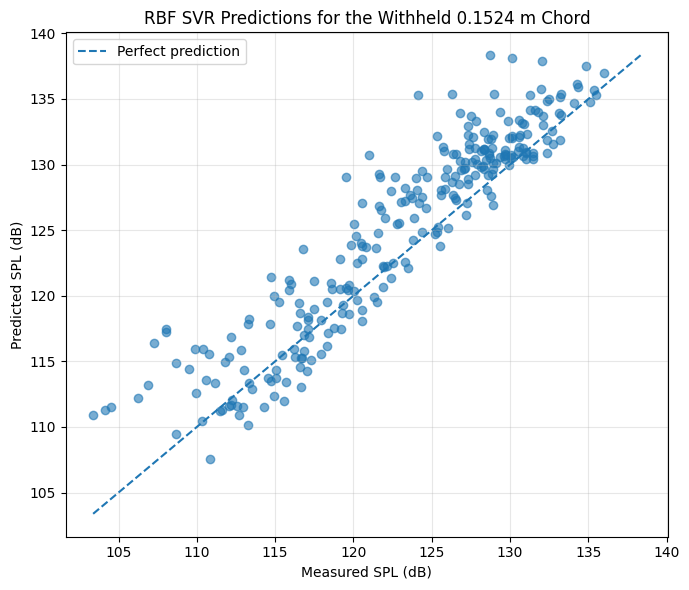

In [29]:
# Extract predictions from the selected RBF SVR
svr_test_predictions = test_predictions["RBF SVR"]

# Define limits shared by both axes
plot_min = min(
    y_test.min(),
    svr_test_predictions.min(),
)

plot_max = max(
    y_test.max(),
    svr_test_predictions.max(),
)

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    svr_test_predictions,
    alpha=0.6,
)

# Perfect-prediction reference line
plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    label="Perfect prediction",
)

plt.xlabel("Measured SPL (dB)")
plt.ylabel("Predicted SPL (dB)")
plt.title(
    "RBF SVR Predictions for the Withheld 0.1524 m Chord"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Residual Analysis

Residuals are calculated as the difference between measured and predicted SPL

Plotting residuals against predicted SPL is used to investigate whether prediction errors are centred around zero or exhibit systematic patterns across the prediction range.

,Statistic,Value (dB)
0,Mean residual,-2.038
1,Residual standard deviation,2.800
2,Largest underprediction,3.663
3,Largest overprediction,-11.217


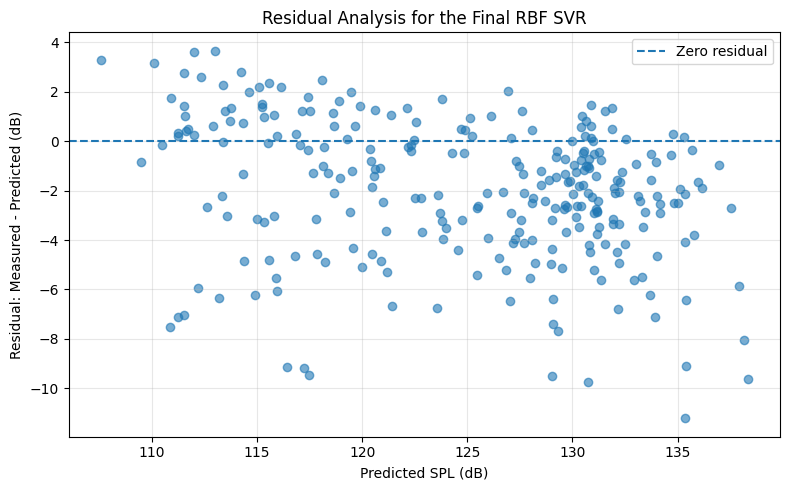

In [30]:
# Calculate residuals for the selected RBF SVR
svr_residuals = (
    y_test.to_numpy()
    - svr_test_predictions
)

# Summarise the residual distribution
residual_summary = pd.DataFrame({
    "Statistic": [
        "Mean residual",
        "Residual standard deviation",
        "Largest underprediction",
        "Largest overprediction",
    ],
    "Value (dB)": [
        svr_residuals.mean(),
        svr_residuals.std(),
        svr_residuals.max(),
        svr_residuals.min(),
    ],
})

display(residual_summary.round(3))

# Plot residuals against predicted SPL
plt.figure(figsize=(8, 5))

plt.scatter(
    svr_test_predictions,
    svr_residuals,
    alpha=0.6,
)

plt.axhline(
    0,
    linestyle="--",
    label="Zero residual",
)

plt.xlabel("Predicted SPL (dB)")
plt.ylabel("Residual: Measured - Predicted (dB)")
plt.title("Residual Analysis for the Final RBF SVR")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The residual analysis indicates that the final RBF SVR displays some systematic overprediction on the withheld chord. The mean residual was −2.038 dB, indicating that predicted SPL was higher than measured SPL on average.

The residual distribution was also asymmetric, with the largest overprediction reaching 11.217 dB compared with a largest underprediction of 3.663 dB.

Therefore, although the SVR achieved the strongest overall test performance with an RMSE of 3.463 dB and \(R^2\) of 0.773, its errors contain systematic error rather than solely random prediction error. This represents an important limitation when applying the model to an unseen chord length.

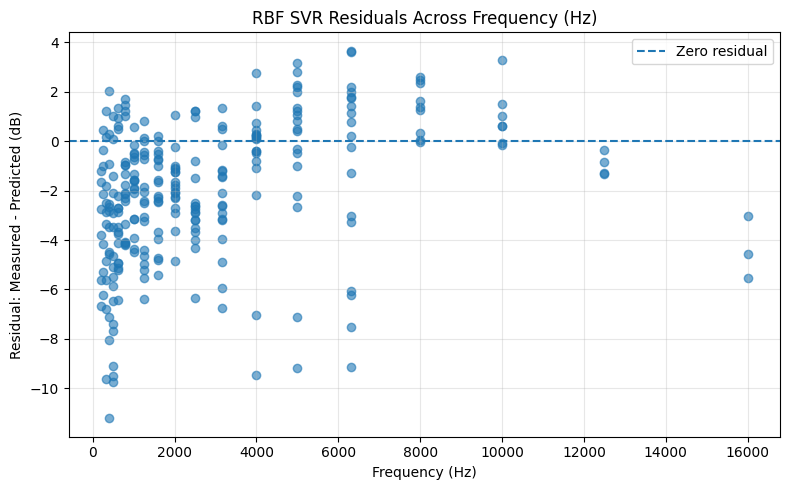

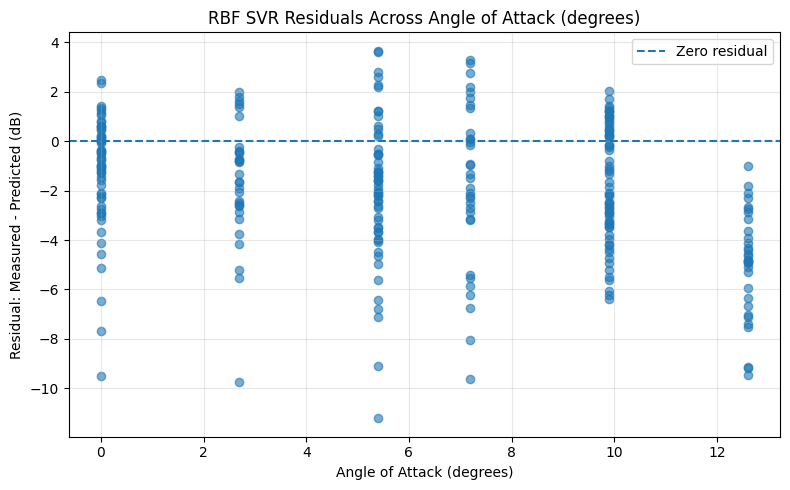

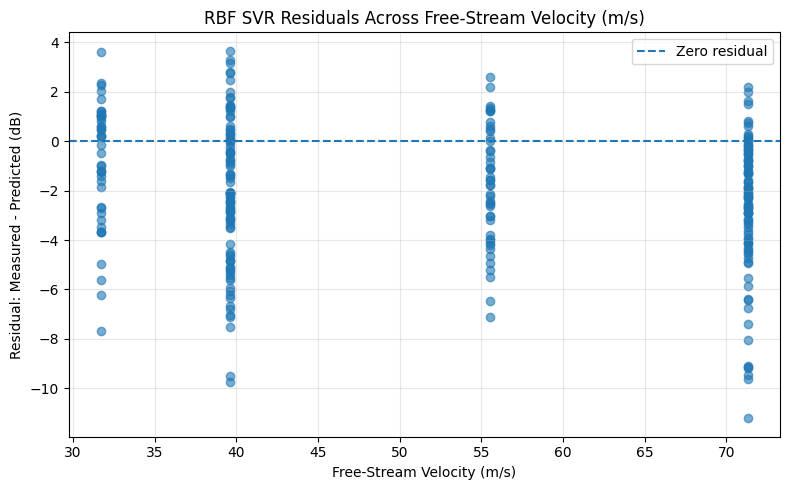

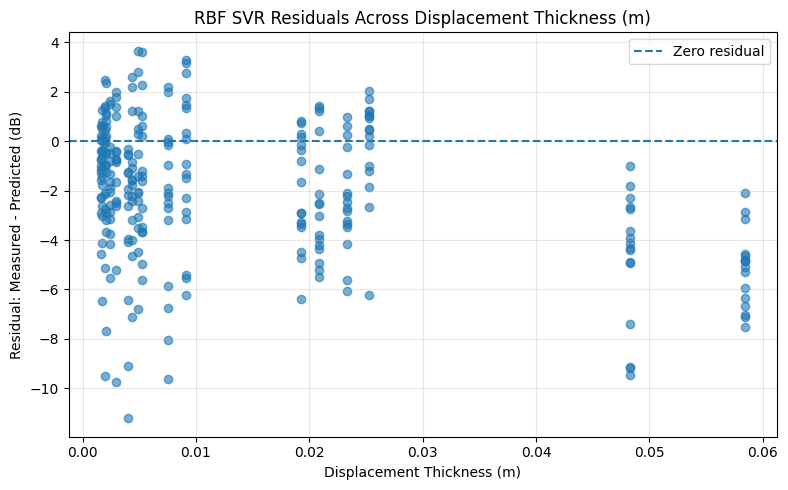

In [31]:
# Examine residuals across the varying test predictors
residual_features = [
    ("frequency", "Frequency (Hz)"),
    ("angle_of_attack", "Angle of Attack (degrees)"),
    ("free_stream_velocity", "Free-Stream Velocity (m/s)"),
    ("displacement_thickness", "Displacement Thickness (m)"),
]

for feature, label in residual_features:

    plt.figure(figsize=(8, 5))

    plt.scatter(
        X_test[feature],
        svr_residuals,
        alpha=0.6,
    )

    plt.axhline(
        0,
        linestyle="--",
        label="Zero residual",
    )

    plt.xlabel(label)
    plt.ylabel("Residual: Measured - Predicted (dB)")
    plt.title(f"RBF SVR Residuals Across {label}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


No monotonic relationship was seen between residual error and frequency, however negative errors occurred across parts of the frequency range. More systematic negative residuals were visible at the highest angle of attack and free stream velocity, indicating greater overprediction for some observations under these conditions.

The clearest pattern occurred at larger displacement thickness values, where residuals were mostly negative. This suggests that the overall overprediction bias is within particular regions of the conditions rather than being distributed across the test data.

These predictors occur in combinations within the experiments, so the plots do not establish that any individual variable causes the observed error. They instead identify operating regions in which the selected SVR appears less reliable.


The untouched 0.1524 m chord provides the independent test of the selected model, for which the RBF SVR achieved an RMSE of 3.463 dB. However, this test contains only one unseen chord length and represents interpolation between chord lengths available during development. The result therefore provides evidence of performance for this particular interpolation but does not establish equivalent performance for other unseen chord lengths or for extrapolation beyond the measured chord range.

## 12. Computational Performance

Computational performance is considered alongside accuracy because training and prediction costs are important when models are applied repeatedly or to larger datasets.

Fit time, prediction time and peak memory usage are compared for each model. Timing measurements are repeated and the median is reported to reduce variation caused by the notebook execution environment.

Models are fitted using the development dataset, while prediction time is measured using the withheld test inputs.


In [32]:

performance_results = []

for model_name, model in comparison_models.items():

    # Median fit time from repeated independent fits
    fit_time = median_ms(
        lambda: clone(model).fit(
            X_development,
            y_development,
        ),
        repeats=10,
    )

    # Fit once before measuring prediction performance
    fitted_model = clone(model).fit(
        X_development,
        y_development,
    )

    # Median prediction time on the withheld test inputs
    prediction_time = median_ms(
        lambda: fitted_model.predict(X_test),
        repeats=20,
    )

    # Measure peak memory during fitting
    tracemalloc.start()

    clone(model).fit(
        X_development,
        y_development,
    )

    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    performance_results.append({
        "Model": model_name,
        "Median Fit Time (ms)": fit_time,
        "Median Prediction Time (ms)": prediction_time,
        "Peak Fit Memory (MB)": peak_memory / (1024 ** 2),
    })


performance_results = pd.DataFrame(performance_results)

display(performance_results.round(3))

,Model,Median Fit Time (ms),Median Prediction Time (ms),Peak Fit Memory (MB)
0,Mean Predictor,0.562,0.092,0.004
1,Multiple Linear Regression,1.958,0.922,0.154
2,Polynomial Regression (degree 2),6.649,2.089,0.610
3,Decision Tree (depth 8),5.783,1.277,0.077
4,RBF SVR,232.656,16.025,0.174


The repeated timing measurements show that the RBF SVR has the highest fitting and prediction cost among the models compared, while the simpler regression and tree models require less computation. Despite these differences, all models remain computationally practical for the current dataset.

The measured timings are specific to the current dataset and  execution environment and may vary between runs. The final timing values are reported directly in the table above.

In [33]:
# Inspect structural measures related to prediction complexity

# Fit the selected decision tree
fitted_tree = clone(
    comparison_models["Decision Tree (depth 8)"]
).fit(
    X_development,
    y_development,
)

# Fit the selected RBF SVR
fitted_svr = clone(
    comparison_models["RBF SVR"]
).fit(
    X_development,
    y_development,
)

tree_depth = fitted_tree.get_depth()
tree_leaves = fitted_tree.get_n_leaves()

svr_support_vectors = (
    fitted_svr
    .named_steps["svr"]
    .support_vectors_
    .shape[0]
)

complexity_summary = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "RBF SVR",
    ],
    "Structural Measure": [
        "Tree depth / leaf nodes",
        "Number of support vectors",
    ],
    "Value": [
        f"{tree_depth} / {tree_leaves}",
        svr_support_vectors,
    ],
})

display(complexity_summary)

,Model,Structural Measure,Value
0,Decision Tree,Tree depth / leaf nodes,8 / 233
1,RBF SVR,Number of support vectors,1169


The selected decision tree has a maximum depth of 8 and 233 leaf nodes. A prediction follows one path through the tree, so the number of comparisons required for an individual prediction is dependent on its depth.

The fitted RBF SVR retained 1,169 support vectors. Prediction with an RBF SVR requires evaluating the new observation relative to the support vectors, so prediction cost depends on the number of support vectors retained. The large number of support vectors is consistent with the higher prediction cost observed for SVR.


In [34]:
# Profile fitting of the selected RBF SVR
profiled_svr = clone(comparison_models["RBF SVR"])

profiler = cProfile.Profile()
profiler.enable()

profiled_svr.fit(
    X_development,
    y_development,
)

profiler.disable()

profile_output = io.StringIO()

profile_stats = pstats.Stats(
    profiler,
    stream=profile_output,
).sort_stats("cumulative")

profile_stats.print_stats(10)

print(profile_output.getvalue())

         6362 function calls (6224 primitive calls) in 0.251 seconds

   Ordered by: cumulative time
   List reduced from 463 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    0.240    0.120 /usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3512(run_code)
        2    0.000    0.000    0.240    0.120 {built-in method builtins.exec}
        1    0.000    0.000    0.240    0.240 /tmp/ipykernel_7859/3987428815.py:1(<cell line: 0>)
      3/1    0.000    0.000    0.240    0.240 /usr/local/lib/python3.13/dist-packages/sklearn/base.py:1372(wrapper)
        1    0.000    0.000    0.240    0.240 /usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:603(fit)
        1    0.000    0.000    0.228    0.228 /usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:153(fit)
        1    0.228    0.228    0.228    0.228 /usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:312(_de

The selected RBF SVR was profiled using cProfile to identify where computation was most heavy during fitting.

Most of the fitting time was spent in scikit learn's SVM fitting function (_dense_fit), rather than data validation. This is consistent with the repeated timing results, where SVR had the highest fitting cost of the models investigated.

## 13. Input Validation

The trained models are intended for prediction within the experimental domain represented by the dataset. Predictions made for operating or geometric conditions outside this range are unsupported by the available training data and may be unreliable.

An input validation function is therefore used to check that prediction inputs are finite, physically valid and within the experimental range before they are supplied to the final model.

The original dataset is documented as containing no missing values. Missing value handling is therefore not required during dataset preprocessing, however, non finite values are checked when accepting new prediction inputs.

In [35]:
# Example of a valid operating condition
valid_input = pd.DataFrame([{
    "frequency": 4000.0,
    "angle_of_attack": 7.2,
    "chord_length": 0.1524,
    "free_stream_velocity": 39.6,
    "displacement_thickness": 0.009,
}])

validate_airfoil_input(valid_input, df)

print("Input validation passed.")

Input validation passed.


In [36]:
# Demonstrate handling of invalid prediction inputs
invalid_examples = {
    "Missing frequency": valid_input.drop(columns=["frequency"]),
    "Zero chord length": valid_input.assign(chord_length=0.0),
    "Frequency outside dataset range": valid_input.assign(
        frequency=25000.0
    ),
}

for description, example in invalid_examples.items():

    try:
        validate_airfoil_input(example, df)

    except ValueError as error:
        print(f"{description}: REJECTED")
        print(f"  {error}")

Missing frequency: REJECTED
  Missing required predictors: ['frequency']
Zero chord length: REJECTED
  Physical predictor values cannot be negative.
Frequency outside dataset range: REJECTED
  frequency must be within the experimental range [200, 20000].


## 14. Conclusions and Limitations

Model performance depends strongly on how generalisation is evaluated.

RBF SVR achieved the lowest mean leave-one-chord-out validation RMSE of **4.296 dB**, compared with **5.002 dB** for linear regression and **6.839 dB** for the mean-predictor baseline. On the untouched **0.1524 m** test chord, the selected SVR achieved an RMSE of **3.463 dB** and an R^2 of **0.773**.

The experiments also showed that greater model complexity does not necessarily improve generalisation. Higher order polynomial models became unstable when predicting unseen chord lengths, while increasingly deep decision trees reduced training error without producing a corresponding improvement in validation error.

### Limitations

The results are limited to the NACA 0012 airfoil and the operating conditions represented by the dataset. Only six chord lengths and four free stream velocities are available, which limits the range over which model generalisation can be assessed.

The final test uses one withheld interior chord length and therefore evaluates interpolation rather than general extrapolation beyond the experimental domain. Residual analysis also identified systematic prediction error for the withheld chord, indicating that prediction accuracy varies across operating conditions.

The model should therefore be treated as a predictive surrogate within the experimental domain rather than as a general airfoil noise model.